In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder


adult_data = fetch_openml(name='adult', version=2, as_frame=True)
df = adult_data.frame

# Changing class column to income
df.rename(columns={'class': 'income'}, inplace=True)


X = df.drop('income', axis=1)
y = df['income']
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include='object').columns

# Train-test split 70-30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
#preprocessors
preprocessors = {
    'StandardScaler + OneHot': ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]),
    'MinMaxScaler + OneHot': ColumnTransformer([
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]),
    'Only OneHotEncoder': ColumnTransformer([
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])
}


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import Pipeline

# Initialize list to store metrics
metrics_data = []

# Loop through each preprocessor and evaluate with Logistic Regression and SVM
for name, preprocessor in preprocessors.items():
    # Logistic Regression
    lr_pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])
    lr_pipeline.fit(X_train, y_train)
    lr_pred = lr_pipeline.predict(X_test)


    lr_precision = precision_score(y_test, lr_pred, pos_label='>50K')
    lr_recall = recall_score(y_test, lr_pred, pos_label='>50K')
    lr_f1 = f1_score(y_test, lr_pred, pos_label='>50K')
    lr_accuracy = accuracy_score(y_test, lr_pred)


    svm_pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', SVC(random_state=42))
    ])
    svm_pipeline.fit(X_train, y_train)
    svm_pred = svm_pipeline.predict(X_test)

    svm_precision = precision_score(y_test, svm_pred, pos_label='>50K')
    svm_recall = recall_score(y_test, svm_pred, pos_label='>50K')
    svm_f1 = f1_score(y_test, svm_pred, pos_label='>50K')
    svm_accuracy = accuracy_score(y_test, svm_pred)

    metrics_data.append({
        'Preprocessing Method': name,
        'Model': 'Logistic Regression',
        'Precision': lr_precision,
        'Recall': lr_recall,
        'F1 Score': lr_f1,
        'Accuracy': lr_accuracy
    })

    metrics_data.append({
        'Preprocessing Method': name,
        'Model': 'SVM',
        'Precision': svm_precision,
        'Recall': svm_recall,
        'F1 Score': svm_f1,
        'Accuracy': svm_accuracy
    })

#Df for metrics
import pandas as pd
metrics_df = pd.DataFrame(metrics_data)


In [ ]:
print("Metrics Summary:\n")
print(metrics_df)

conclusion = ""
for name in preprocessors:
    lr_accuracy = metrics_df[(metrics_df['Preprocessing Method'] == name) & (metrics_df['Model'] == 'Logistic Regression')]['Accuracy'].values[0]
    svm_accuracy = metrics_df[(metrics_df['Preprocessing Method'] == name) & (metrics_df['Model'] == 'SVM')]['Accuracy'].values[0]

    if lr_accuracy > svm_accuracy:
        conclusion += f"\nWith {name}, Logistic Regression outperforms SVM."
    elif svm_accuracy > lr_accuracy:
        conclusion += f"\nWith {name}, SVM outperforms Logistic Regression."
    else:
        conclusion += f"\nWith {name}, Logistic Regression and SVM perform equally well."

print(conclusion)


Metrics Summary:

      Preprocessing Method                Model  Precision    Recall  \
0  StandardScaler + OneHot  Logistic Regression   0.701042  0.393567   
1  StandardScaler + OneHot                  SVM   0.772808  0.383918   
2    MinMaxScaler + OneHot  Logistic Regression   0.697662  0.375146   
3    MinMaxScaler + OneHot                  SVM   0.781529  0.358772   
4       Only OneHotEncoder  Logistic Regression   0.701407  0.393567   
5       Only OneHotEncoder                  SVM   0.955519  0.169591   

   F1 Score  Accuracy  
0  0.504120  0.819286  
1  0.512991  0.829864  
2  0.487925  0.816215  
3  0.491784  0.826930  
4  0.504214  0.819354  
5  0.288056  0.804340  

With StandardScaler + OneHot, SVM outperforms Logistic Regression.
With MinMaxScaler + OneHot, SVM outperforms Logistic Regression.
With Only OneHotEncoder, Logistic Regression outperforms SVM.


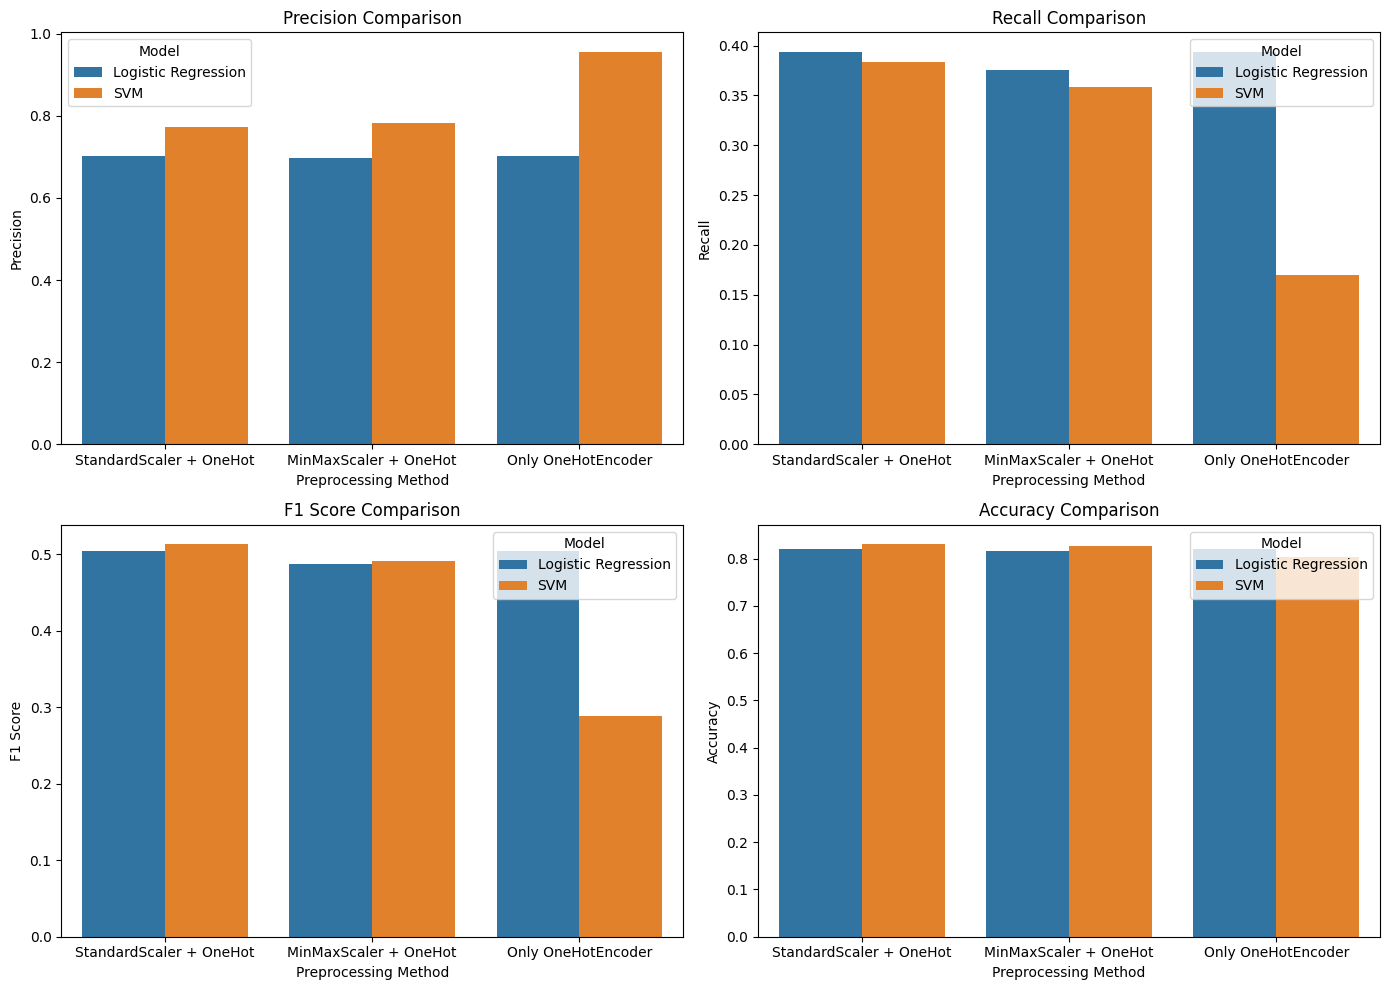

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot comparison using seaborn
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precision Plot
sns.barplot(data=metrics_df, x='Preprocessing Method', y='Precision', hue='Model', ax=axes[0, 0])
axes[0, 0].set_title('Precision Comparison')

# Recall Plot
sns.barplot(data=metrics_df, x='Preprocessing Method', y='Recall', hue='Model', ax=axes[0, 1])
axes[0, 1].set_title('Recall Comparison')

# F1 Score Plot
sns.barplot(data=metrics_df, x='Preprocessing Method', y='F1 Score', hue='Model', ax=axes[1, 0])
axes[1, 0].set_title('F1 Score Comparison')

# Accuracy Plot
sns.barplot(data=metrics_df, x='Preprocessing Method', y='Accuracy', hue='Model', ax=axes[1, 1])
axes[1, 1].set_title('Accuracy Comparison')

plt.tight_layout()
plt.show()
